In [4]:
import warnings
import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import (
    GradientBoostingClassifier,
    IsolationForest,
    RandomForestClassifier,
)
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    PrecisionRecallDisplay,
    RocCurveDisplay,
    accuracy_score,
    average_precision_score,
    classification_report,
    f1_score,
    precision_recall_fscore_support,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import (
    StratifiedKFold,
    learning_curve,
    train_test_split,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier

# Ignore unnecessary warning messages during model training
warnings.filterwarnings('ignore')

print('====================================================================')
print('=== COMPONENT 4: AGENCY BANKING HYBRID FRAUD DETECTION ANALYTICS ===')
print('====================================================================\n')

=== COMPONENT 4: AGENCY BANKING HYBRID FRAUD DETECTION ANALYTICS ===



In [5]:
# =========================================================================
# STEP 1: DATA LOADING & PRELIMINARY CLEANING
# =========================================================================
# Load transaction dataset
df = pd.read_csv('paysim.csv')

# Drop duplicate records to avoid model bias
df = df.drop_duplicates().reset_index(drop=True)

# Drop non-predictive identifiers and raw timestamp columns safely
df = df.drop(columns=['bank_txn_id', 'date'], errors='ignore')


In [6]:
# =========================================================================
# STEP 2: RECOMMENDED ML UPGRADE - ADVANCED FEATURE ENGINEERING
# =========================================================================

# --- Feature Engineering A: Z-Score Outlier Check for Extreme Amounts ---
# Flag transactions that deviate significantly from average transaction amounts
if 'amount_zscore' in df.columns:
  df['is_high_zscore'] = (df['amount_zscore'].abs() > 2.0).astype(int)


# --- Feature Engineering B: Unsupervised Isolation Forest Anomaly Scoring ---
# Extract numeric columns for unsupervised anomaly detection
iso_num_cols = df.select_dtypes(include=['float64', 'int64']).columns.drop(
    'target_anomaly', errors='ignore'
)

# Impute missing numerical values before running Isolation Forest
iso_imputer = SimpleImputer(strategy='median')
iso_data = iso_imputer.fit_transform(df[iso_num_cols])

# Train Isolation Forest to detect unknown/unlabeled fraud patterns
iso_forest = IsolationForest(
    n_estimators=100, contamination=0.05, random_state=42, n_jobs=-1
)

# Convert Isolation Forest output (-1 = Outlier, 1 = Normal) into binary score (1 = Anomaly, 0 = Normal)
df['unsupervised_anomaly_score'] = (
    iso_forest.fit_predict(iso_data) == -1
).astype(int)


In [7]:
# =========================================================================
# STEP 3: TARGET & FEATURE DEFINITION AND PREPROCESSING SETUP
# =========================================================================
# Separate dependent target variable (y) and independent features (X)
y = df['target_anomaly'].astype(int)
X = df.drop(columns=['target_anomaly'])

# Print baseline anomaly distribution
anomaly_rate = y.mean() * 100
print(f'Dataset Size     : {len(df)} transactions')
print(f'Anomaly Rate     : {anomaly_rate:.2f}%\n')

# Separate categorical and numerical feature columns
cat_cols = ['txn_type', 'direction', 'channel']
cat_cols = [c for c in cat_cols if c in X.columns]
num_cols = [c for c in X.columns if c not in cat_cols]

# Define Scikit-Learn Pipeline ColumnTransformer for scaling & encoding
preprocessor = ColumnTransformer([
    (
        'cat',
        Pipeline([
            ('imp', SimpleImputer(strategy='most_frequent')),
            ('ohe', OneHotEncoder(handle_unknown='ignore')),
        ]),
        cat_cols,
    ),
    (
        'num',
        Pipeline([
            ('imp', SimpleImputer(strategy='median')),
            ('sc', StandardScaler()),
        ]),
        num_cols,
    ),
])


Dataset Size     : 164260 transactions
Anomaly Rate     : 5.00%



In [8]:
# =========================================================================
# STEP 4: TRAIN-TEST SPLIT & MODEL PIPELINE DEFINITIONS
# =========================================================================
# Perform 80/20 Stratified Train-Test Split to preserve class imbalance ratio
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# Calculate scale_pos_weight for handling class imbalance in gradient boosting
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

# Define dictionary of classification algorithms wrapped in Scikit-Learn Pipelines
models = {
    'LogisticRegression': Pipeline([
        ('pre', preprocessor),
        (
            'm',
            LogisticRegression(
                max_iter=1000, class_weight='balanced', random_state=42
            ),
        ),
    ]),
    'DecisionTree': Pipeline([
        ('pre', preprocessor),
        (
            'm',
            DecisionTreeClassifier(
                max_depth=8, class_weight='balanced', random_state=42
            ),
        ),
    ]),
    'RandomForest': Pipeline([
        ('pre', preprocessor),
        (
            'm',
            RandomForestClassifier(
                n_estimators=200,
                class_weight='balanced',
                n_jobs=-1,
                random_state=42,
            ),
        ),
    ]),
}

# Optional XGBoost Integration if library is installed in local environment
try:
  from xgboost import XGBClassifier

  models['XGBoost'] = Pipeline([
      ('pre', preprocessor),
      (
          'm',
          XGBClassifier(
              n_estimators=300,
              max_depth=5,
              learning_rate=0.1,
              subsample=0.9,
              scale_pos_weight=scale_pos_weight,
              eval_metric='logloss',
              random_state=42,
          ),
      ),
  ])
except ImportError:
  print('Notice: XGBoost not installed. Training with sklearn models.')


In [9]:
# =========================================================================
# STEP 5: MODEL TRAINING, BENCHMARKING & CHAMPION SELECTION
# =========================================================================
print('=== Running Model Comparison (Focused on PR-AUC & Precision/Recall) ===')
pr_auc_scores = {}
roc_auc_scores = {}
fitted_models = {}

# Train each model and evaluate on test dataset
for name, m in models.items():
  m.fit(X_train, y_train)
  fitted_models[name] = m

  # Calculate prediction probabilities and binary class predictions
  proba = m.predict_proba(X_test)[:, 1]
  pred = m.predict(X_test)

  # Calculate evaluation metrics
  roc_auc = roc_auc_score(y_test, proba)
  pr_auc = average_precision_score(y_test, proba)
  pr, rc, f1, _ = precision_recall_fscore_support(
      y_test, pred, average='binary', zero_division=0
  )

  roc_auc_scores[name] = roc_auc
  pr_auc_scores[name] = pr_auc

  print(
      f'  {name:18s} | PR-AUC: {pr_auc:.3f} | ROC-AUC: {roc_auc:.3f} | Prec:'
      f' {pr:.2f} | Rec: {rc:.2f} | F1: {f1:.2f}'
  )

# Select Champion Model based on highest PR-AUC score (best metric for imbalanced fraud data)
best_name = max(pr_auc_scores, key=pr_auc_scores.get)
print(f'\n🏆 Champion Anomaly Model Selected: {best_name}')

champion_model = fitted_models[best_name]

# Generate predictions from Champion Model
y_pred = champion_model.predict(X_test)
y_proba = champion_model.predict_proba(X_test)[:, 1]

print('\n===================================================')
print(f'=== Champion Model ({best_name}) Performance ===')
print('===================================================')
print(f'Accuracy  : {accuracy_score(y_test, y_pred):.3f}')
print(f'Precision : {precision_score(y_test, y_pred):.3f}')
print(f'Recall    : {recall_score(y_test, y_pred):.3f}')
print(f'F1-Score  : {f1_score(y_test, y_pred):.3f}')
print(f'ROC-AUC   : {roc_auc_score(y_test, y_proba):.3f}')
print(f'PR-AUC    : {average_precision_score(y_test, y_proba):.3f}\n')
print(
    classification_report(y_test, y_pred, target_names=['Normal', 'Anomaly'])
)


=== Running Model Comparison (Focused on PR-AUC & Precision/Recall) ===
  LogisticRegression | PR-AUC: 0.466 | ROC-AUC: 0.907 | Prec: 0.19 | Rec: 0.81 | F1: 0.31
  DecisionTree       | PR-AUC: 0.507 | ROC-AUC: 0.913 | Prec: 0.23 | Rec: 0.79 | F1: 0.35
  RandomForest       | PR-AUC: 0.431 | ROC-AUC: 0.891 | Prec: 0.38 | Rec: 0.44 | F1: 0.41
  XGBoost            | PR-AUC: 0.518 | ROC-AUC: 0.914 | Prec: 0.23 | Rec: 0.79 | F1: 0.36

🏆 Champion Anomaly Model Selected: XGBoost

=== Champion Model (XGBoost) Performance ===
Accuracy  : 0.859
Precision : 0.232
Recall    : 0.786
F1-Score  : 0.359
ROC-AUC   : 0.914
PR-AUC    : 0.518

              precision    recall  f1-score   support

      Normal       0.99      0.86      0.92     31209
     Anomaly       0.23      0.79      0.36      1643

    accuracy                           0.86     32852
   macro avg       0.61      0.82      0.64     32852
weighted avg       0.95      0.86      0.89     32852



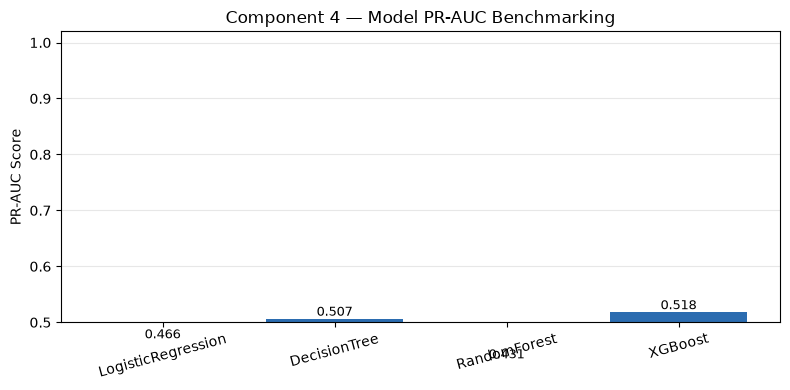

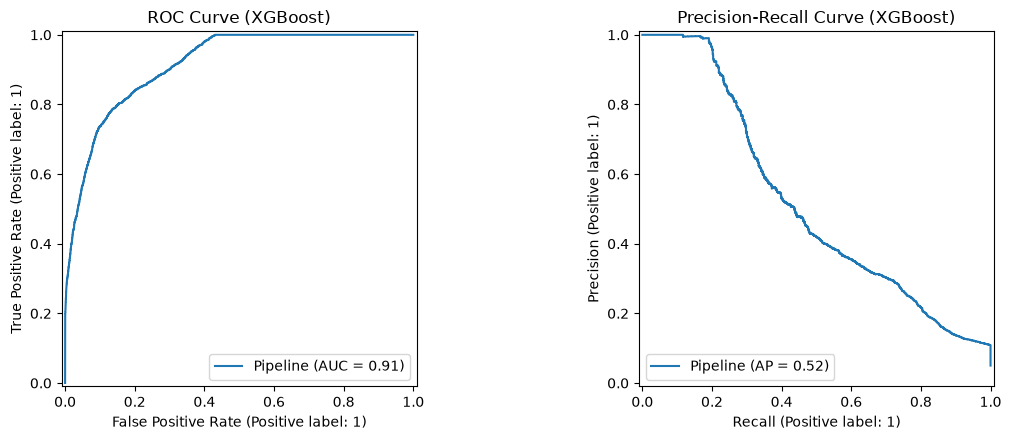

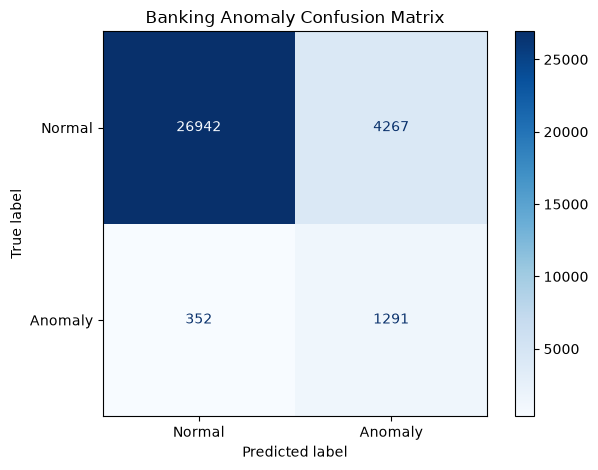

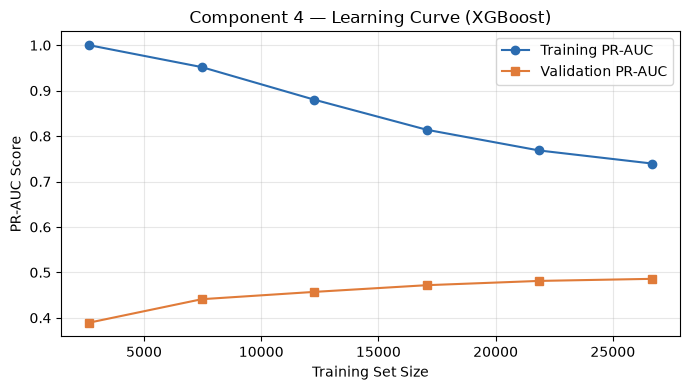

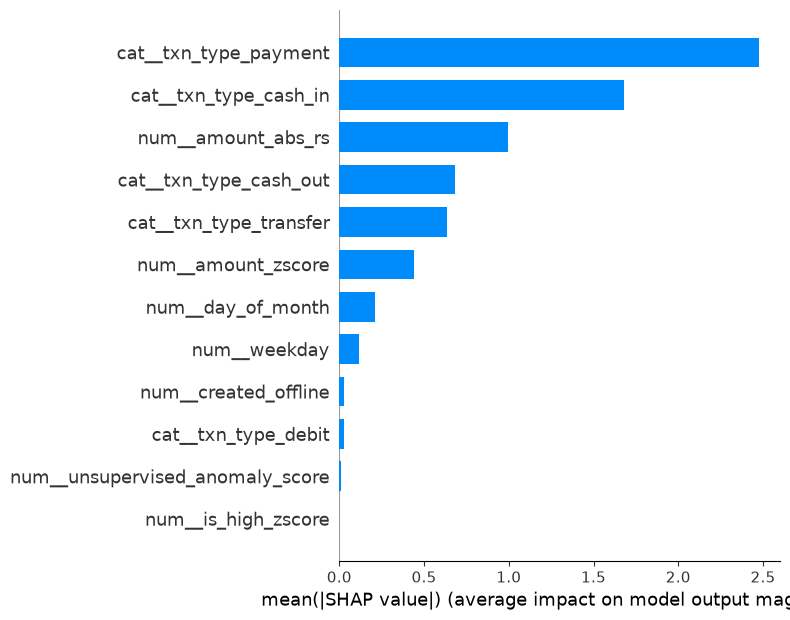

In [10]:
# =========================================================================
# STEP 6: VISUALIZATIONS & PERFORMANCE CHARTS
# =========================================================================

# --- Chart 1: Model PR-AUC Comparison Bar Chart ---
plt.figure(figsize=(8, 4))
bars = plt.bar(pr_auc_scores.keys(), pr_auc_scores.values(), color='#2b6cb0')
for b, v in zip(bars, pr_auc_scores.values()):
  plt.text(
      b.get_x() + b.get_width() / 2,
      v + 0.005,
      f'{v:.3f}',
      ha='center',
      fontsize=9,
  )
plt.ylim(0.5, 1.02)
plt.ylabel('PR-AUC Score')
plt.title('Component 4 — Model PR-AUC Benchmarking')
plt.xticks(rotation=15)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# --- Chart 2: ROC Curve & Precision-Recall Curve ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
RocCurveDisplay.from_estimator(champion_model, X_test, y_test, ax=axes[0])
axes[0].set_title(f'ROC Curve ({best_name})')

PrecisionRecallDisplay.from_estimator(
    champion_model, X_test, y_test, ax=axes[1]
)
axes[1].set_title(f'Precision-Recall Curve ({best_name})')
plt.tight_layout()
plt.show()

# --- Chart 3: Confusion Matrix ---
ConfusionMatrixDisplay.from_estimator(
    champion_model,
    X_test,
    y_test,
    display_labels=['Normal', 'Anomaly'],
    cmap='Blues',
)
plt.title('Banking Anomaly Confusion Matrix')
plt.tight_layout()
plt.show()

# --- Chart 4: Subsampled Learning Curve ---
sample_size = min(40000, len(X))
idx = np.random.RandomState(42).choice(len(X), sample_size, replace=False)

sizes, tr, val = learning_curve(
    champion_model,
    X.iloc[idx],
    y.iloc[idx],
    cv=StratifiedKFold(3, shuffle=True, random_state=42),
    scoring='average_precision',
    train_sizes=np.linspace(0.1, 1.0, 6),
    n_jobs=-1,
)

plt.figure(figsize=(7, 4))
plt.plot(sizes, tr.mean(1), 'o-', label='Training PR-AUC', color='#2b6cb0')
plt.plot(sizes, val.mean(1), 's-', label='Validation PR-AUC', color='#e07b39')
plt.xlabel('Training Set Size')
plt.ylabel('PR-AUC Score')
plt.title(f'Component 4 — Learning Curve ({best_name})')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# --- Chart 5: SHAP Model Explainability Feature Importance ---
try:
  import shap

  # Transform test subset through pipeline preprocessor
  Xt = champion_model.named_steps['pre'].transform(X_test[:2000])
  Xt = Xt.toarray() if hasattr(Xt, 'toarray') else np.asarray(Xt)
  Xt = Xt.astype(float)

  feat_names = champion_model.named_steps['pre'].get_feature_names_out()
  explainer = shap.TreeExplainer(champion_model.named_steps['m'])
  shap_values = explainer.shap_values(Xt)

  plt.figure(figsize=(8, 4.5))
  if isinstance(shap_values, list):
    shap.summary_plot(
        shap_values[1],
        features=Xt,
        feature_names=feat_names,
        plot_type='bar',
        max_display=12,
    )
  else:
    shap.summary_plot(
        shap_values,
        features=Xt,
        feature_names=feat_names,
        plot_type='bar',
        max_display=12,
    )
except Exception as e:
  print(f'Notice: SHAP analysis skipped ({e}).')


In [11]:
# =========================================================================
# STEP 7: RECOMMENDED ML UPGRADE - REAL-TIME DYNAMIC POLICY ENGINE
# =========================================================================
print('===================================================')
print('=== REAL-TIME TRANSACTION FRAUD RISK ADVISORY ===')
print('===================================================')

# Pick sample flagged anomaly transaction for real-time inference demonstration
anomaly_indices = np.where(y_pred == 1)[0]
sample_idx = anomaly_indices[0] if len(anomaly_indices) > 0 else 0

sample_txn = X_test.iloc[[sample_idx]].copy()

# Calculate dynamic fraud risk percentage score (0% - 100%)
anomaly_score = round(champion_model.predict_proba(sample_txn)[0, 1] * 100, 2)

print(f'Transaction Ref Index : {sample_idx}')
print(f'Calculated Fraud Risk : {anomaly_score}%')

# Multi-tier Dynamic Policy Threshold Rules for banking operations
if anomaly_score >= 75:
  recommendation = (
      '🚩 CRITICAL RISK: BLOCK TRANSACTION & TRIGGER BIOMETRIC/OTP'
  )
elif anomaly_score >= 45:
  recommendation = '⚠️ MEDIUM RISK: HOLD FOR MANUAL AUDIT / AGENT VERIFICATION'
else:
  recommendation = '✅ LOW RISK: APPROVE TRANSACTION INSTANTLY'

print(f'System Action Advice  : {recommendation}')


=== REAL-TIME TRANSACTION FRAUD RISK ADVISORY ===
Transaction Ref Index : 8
Calculated Fraud Risk : 52.310001373291016%
System Action Advice  : ⚠️ MEDIUM RISK: HOLD FOR MANUAL AUDIT / AGENT VERIFICATION


In [12]:
# =========================================================================
# STEP 8: MODEL ARTIFACT SERIALIZATION (SAVING PIPELINE)
# =========================================================================
# Save champion model pipeline to disk for API / Production deployment
model_filename = 'component4_banking_anomaly_model.pkl'
joblib.dump(champion_model, model_filename)
print(f'\n✅ Upgraded Model saved successfully as "{model_filename}"')


✅ Upgraded Model saved successfully as "component4_banking_anomaly_model.pkl"
